In [169]:
import math
from typing import Callable, Any
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mpc 
from joblib import Parallel, delayed, dump, load
from PIL import Image
import numpy as np
from IPython.display import HTML, display

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="sans-serif",
)

Wszystkie wygenerowane obrazki znajdują się w folderze `./figs`. Wygenerowane animacje w folderze `./gifs` (rozdzielczość 512x512) i w `./gifs_300x300` (rozdzielczość 300x300). Docelowa rozdzielczość generowanych obrazów to `512x512`.

# Pomocnicze funkcje do wizualizacji

In [170]:
def plot_grid(grid: np.ndarray):
    fig, ax = plt.subplots(figsize=(0.5, 0.5), dpi=900)
    ax.imshow(grid, cmap='binary')
    ax.axis('off')
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    plt.show() 


def plot_grid_solution(energy_log: list[float], temperature_log: list[float], grid: np.ndarray):
    _, (ax_energy, ax_grid) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), layout="constrained")

    ax_energy.plot(energy_log, color='blue', alpha=0.8, label='Energy')
    ax_energy.set_title('Energy and Temperature over Time', fontweight='bold')
    ax_energy.set_xlabel('Epoch') 
    ax_energy.set_ylabel('Energy', color='blue')
    ax_energy.tick_params(axis='y', labelcolor='blue')
    ax_energy.grid(True, color='silver', linestyle='--', linewidth=0.7, alpha=0.7)

    ax_temp = ax_energy.twinx()
    ax_temp.plot(temperature_log, color='red', alpha=0.8, label='Temperature', zorder=5)
    ax_temp.set_ylabel('Temperature', color='red')
    ax_temp.tick_params(axis='y', labelcolor='red')

    ax_grid.imshow(grid, cmap='binary')
    ax_grid.set_title('Grid Solution', fontweight='bold')
    ax_grid.axis('off') 

    plt.show()


def save_frames_as_gif(
    frames: list[np.ndarray], 
    filename: str = "annealing.gif", 
    fps: int = 20, 
) -> None:
    if not frames:
        return

    pil_images = []

    for frame in frames:
        pixel_data = (255 - frame * 255).astype(np.uint8)
        img = Image.fromarray(pixel_data, mode='L')
        pil_images.append(img)

    pil_images[0].save(
        filename,
        save_all=True,
        append_images=pil_images[1:],
        duration=1000 // fps,
        loop=0
    )

    print(f"saved to {filename}")

In [171]:
def plot_patterns(shapes: list[tuple[str, list[tuple[int, int]]]], cols: int = 3):
    rows = math.ceil(len(shapes) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    cmap = mpc.ListedColormap(['white', '#1f1f1f', '#e28743'])

    for idx, (name, offsets) in enumerate(shapes):
        ax = axes[idx]
        
        all_r = [r for r, c in offsets] + [0]
        all_c = [c for r, c in offsets] + [0]
        
        min_r, max_r = min(all_r) - 1, max(all_r) + 1
        min_c, max_c = min(all_c) - 1, max(all_c) + 1
        
        height = max_r - min_r + 1
        width  = max_c - min_c + 1
        
        grid = np.zeros((height, width), dtype=int)
        
        for r, c in offsets:
            grid[r - min_r, c - min_c] = 1
            
        grid[0 - min_r, 0 - min_c] = 2
        
        ax.imshow(grid, cmap=cmap, vmin=0, vmax=2)
        ax.set_title(name, fontsize=14, fontweight='bold', pad=10)
        ax.grid(which="minor", color="black", linestyle='--', linewidth=0.5, alpha=0.3)
        
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.set_xticks([])
        ax.set_yticks([])

    for idx in range(len(shapes), len(axes)):
        fig.delaxes(axes[idx])

    plt.title("Neighbourhoods")
    plt.tight_layout()
    plt.show()

# Generowanie początkowego obrazka

In [172]:
def generate_grid(n: int, density: float) -> np.ndarray:
    total_cells = n * n
    num_ones = int(total_cells * density)

    grid = np.zeros((n, n), dtype=np.int64)
    flat_indices = np.random.choice(total_cells, num_ones, replace=False)

    for flat_idx in flat_indices:
        r, c = divmod(flat_idx, n)
        grid[r, c] = 1

    return grid

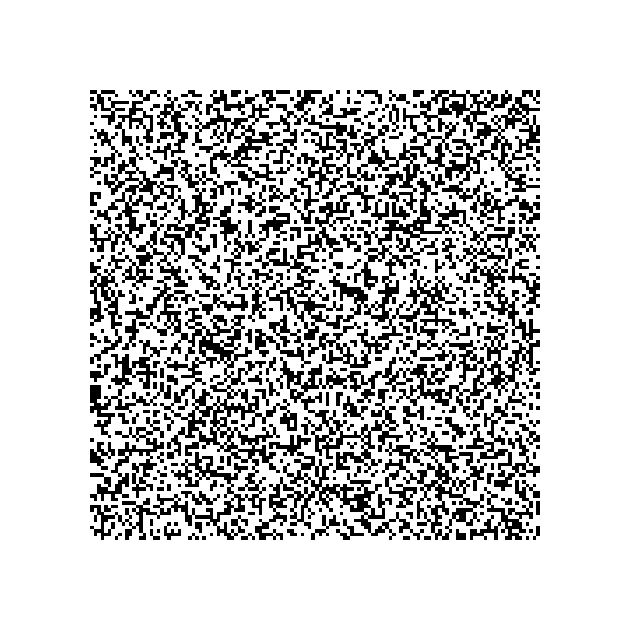

In [173]:
plot_grid(generate_grid(128, 0.4))

# Rozważane sąsiedztwa

In [174]:
STAR_SHAPE = [
    (0, 1),
    (0, -1),
    (1, 0),
    (-1, 0),
]

SPIRAL_SHAPE = [
    (-1,  0), (-2,  0), (-2, -1), (-2, -2), 
    (-1, -2), ( 0, -2), ( 1, -2), ( 2, -2), 
    ( 2, -1), ( 2,  0), ( 2,  1), ( 2,  2), 
    ( 1,  2), ( 0,  2), (-1,  2), (-2,  2)
]

STAIRCASE_SHAPE = [
    (-2, -2),  
    (-1, -2),  
    (-1, -1),  
    ( 0, -1),  
    ( 1,  0),  
    ( 1,  1),  
    ( 2,  1),  
    ( 2,  2)   
]

H_SHAPE_SHAPE = [
    (-2, -2),  
    (-2, -1),  
    (-1, -1),  
    ( 0, -1),   
    ( 1, -2),  
    ( 2, -2),  
    (-2,  2),  
    (-1,  2),  
    ( 0,  1),  
    ( 1,  1),  
    ( 2,  1),  
    ( 2,  2)   
]

MOORE_SHAPE = [
    (-1, -1),
    (-1,  0),
    (-1,  1),
    ( 0, -1),
    ( 0,  1),
    ( 1, -1),
    ( 1,  0),
    ( 1,  1)
]

MOSS_SHAPE = [
    (-5, -1), (-5,  0),                           
    (-4, -2), (-4, -1), (-4,  3),                
    (-3, -4), (-3, -3), (-3, -2), (-3, -1), (-3,  3), 
    (-2, -5), (-2, -1), (-2,  0), (-2,  2),      
    (-1, -1), (-1,  0), (-1,  1),                 
    ( 0,  1), ( 0,  2),                           
    ( 1,  0), ( 1,  1), ( 1,  3), ( 1,  4),       
    ( 2, -1), ( 2,  0),                           
    ( 3, -2), ( 3, -1),                           
    ( 4, -2)                                      
]

SHAPES = [
    ("star", STAR_SHAPE),
    ("spiral", SPIRAL_SHAPE),
    ("staircase", STAIRCASE_SHAPE),
    ("h", H_SHAPE_SHAPE),
    ("moore", MOORE_SHAPE),
    ("moss", MOSS_SHAPE)
]

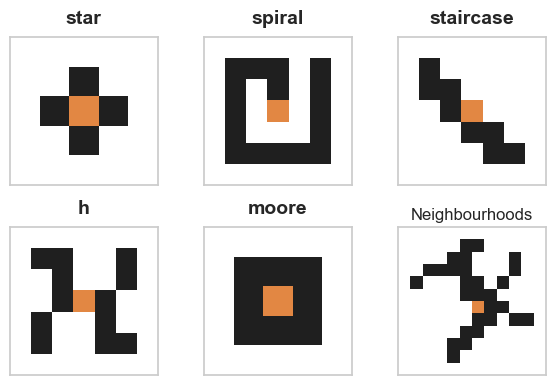

In [175]:
plot_patterns(SHAPES)

# Implementacja wyżarzania

In [176]:
def annealing_schedule_exp(decay_factor: float = 0.9999):
    def schedule(t: float, _: int):
        return t * decay_factor

    return schedule

## Funkcje energii

In [177]:
def cost_attract(x: np.ndarray, r1: int, c1: int, r2: int, c2: int):
    """
    Indices of the same color want to be close together.
    """

    if x[r1, c1] == x[r2, c2]:
        return 0
    
    return 1


def cost_repulse(x: np.ndarray, r1: int, c1: int, r2: int, c2: int):
    """
    Indices of the same color don't want to be together.
    """

    return 1 - cost_attract(x, r1, c1, r2, c2)

In [ ]:
def local_energy(x: np.ndarray, row: int, col: int, shape: list[tuple[int, int]], cost):
    """
    Calculates the local energy of a given pixel when `shape` is used.
    """

    if x[row][col] == 0:
        return 0
    
    n, _ = x.shape
    energy = 0

    for dr, dc in shape:
        energy += cost(x, row, col, (row + dr) % n, (col + dc) % n)

    return energy


def energy_fn_factory(shape: list[tuple[int, int]], cost) -> float:
    def energy_fn(x: np.ndarray) -> float:
        n, _ = x.shape
        energy = 0

        for row in range(n):
            for col in range(n):
                energy += local_energy(x, row, col, shape, cost)

        return energy 

    return energy_fn

## Funkcje przejścia

In [179]:
def swap_neighbours(x: np.ndarray) -> tuple[tuple[int, int], tuple[int, int]]:
    """
    Returns two neighbouring cells to swap.
    """

    n, _ = x.shape
    neighbourhood = [(-1, 0), (1, 0), (0, -1), (0, 1)] 

    while True:
        r1 = np.random.randint(0, n)
        c1 = np.random.randint(0, n)
        
        move_idx = np.random.randint(0, 4)
        dr, dc = neighbourhood[move_idx]
        
        r2 = (r1 + dr) % n
        c2 = (c1 + dc) % n 

        # Make sure we are swapping cells of 
        # different colours 

        if x[r1, c1] != x[r2, c2]:
            return (r1, c1), (r2, c2)
        

def swap_arbitrary(x: np.ndarray) -> tuple[tuple[int, int], tuple[int, int]]:
    """
    Returns two arbitrary cells to swap.
    """

    n, _ = x.shape

    while True:
        r1 = np.random.randint(0, n)
        c1 = np.random.randint(0, n)

        r2 = np.random.randint(0, n)
        c2= np.random.randint(0, n)
        
        # Make sure we are swapping cells of 
        # different colours 

        if x[r1, c1] != x[r2, c2]:
            return (r1, c1), (r2, c2)

In [180]:
def transition_fn_factory(swap_fn: Callable[[np.ndarray], tuple[tuple[int, int], tuple[int, int]]], shape: list[tuple[int, int]], cost):
    def transition_fn(x: np.ndarray) -> tuple[float, Callable[[], Any]]:
        (r1, c1), (r2, c2) = swap_fn(x)

        n, _ = x.shape
        affected_cells = set()

        # NOTE: We look for cells from which we can reach the swapped cells
        #       so that we can compute delta y.

        for r, c in [(r1, c1), (r2, c2)]:
            affected_cells.add((r, c))

            for dr, dc in shape:
                affected_r = (r - dr) % n
                affected_c = (c - dc) % n
                affected_cells.add((affected_r, affected_c))

        old_energy = sum(local_energy(x, r, c, shape, cost) for r, c in affected_cells)
        val1, val2 = x[r1, c1], x[r2, c2]

        # Compute energy after swap

        x[r1, c1], x[r2, c2] = val2, val1
        new_energy = sum(local_energy(x, r, c, shape, cost) for r, c in affected_cells)
        x[r1, c1], x[r2, c2] = val1, val2

        # Figure out delta y

        delta_y = new_energy - old_energy

        def apply():
            x[r1, c1], x[r2, c2] = val2, val1

        return delta_y, apply

    return transition_fn

## Wyżarzanie

In [181]:
def estimate_initial_temperature(
    x: np.ndarray,
    delta_fn: Callable[[np.ndarray], float],
    initial_acceptance = 0.8,
    iterations = 1000
) -> float:
    """
    Figures out initial temperature for the given transition function
    that results in initial_acceptance% rate of higher energy states 
    at the beginning of the annealing process.
    """

    positive_energy_changes = 0
    no_positive_energy_changes = 0

    for _ in range(iterations):
        delta_y = delta_fn(x)

        if delta_y > 0:
            no_positive_energy_changes += 1
            positive_energy_changes += delta_y

    positive_energy_changes /= no_positive_energy_changes
    t = -positive_energy_changes / np.log(initial_acceptance)

    return t

In [182]:
def annealing(
    x: np.ndarray,
    t: float,
    transition_fn: Callable[[np.ndarray], tuple[float, Callable[[np.ndarray], None]]],
    energy_fn: Callable[[np.ndarray], float],
    annealing_schedule: Callable[[float, int], float],
    hook_fn: Callable[[np.ndarray], None] | None = None,
    hook_step: int = 100,
    max_epochs: int = 10000,
    epoch_size: int = 75,
):
    y = energy_fn(x)
    x_best, y_best = x.copy(), y

    energy_log = [y]
    temp_log = [t]

    for epoch in range(max_epochs):
        if epoch % hook_step == 0 and hook_fn:
            hook_fn(x.copy())

        for _ in range(epoch_size):
            delta_y, apply = transition_fn(x)

            if delta_y <= 0 or np.random.uniform() < np.exp(-delta_y / t):
                apply()
                y += delta_y

                if y < y_best:
                    x_best, y_best = x.copy(), y

        energy_log.append(y)
        temp_log.append(t)
        t = annealing_schedule(t, epoch)

        if t < 1e-10:
            break

    if hook_fn:
        hook_fn(x_best)

    return x_best, y_best, energy_log, temp_log

# Obliczanie wyników

Obliczenia zostały zrównoleglone z pomocą biblioteki `joblib`.

In [183]:
def generate(n_jobs=-1):
    def process(cost_fn, swap_fn, density, name, shape, cooling):
        x = generate_grid(512, density)

        n, _ = x.shape
        cost_name = cost_fn.__name__
        swap_name = swap_fn.__name__ 
        casename = f"{name}_{cost_name}_s{swap_name}_d{density}_c{cooling}_{n}x{n}"

        print(f"processing: {casename}")
    
        transition_fn = transition_fn_factory(swap_fn, shape, cost_fn)
        energy_fn = energy_fn_factory(shape, cost_fn)
    
        t = estimate_initial_temperature(
            x,
            delta_fn=lambda state: transition_fn(state)[0]
        )
    
        frames = []
        def hook_fn(current_x: np.ndarray):
            frames.append(current_x) 
    
        result, _, energy_log, temperature_log = annealing(
            x=x.copy(),
            t=t,
            transition_fn=transition_fn,
            energy_fn=energy_fn,
            annealing_schedule=annealing_schedule_exp(cooling),
            hook_fn=hook_fn,
        )
    
        filename = f"./gifs/{casename}.gif"
        save_frames_as_gif(frames, filename)
        plt.imsave(f"./figs/{casename}.png", result, cmap='binary')
        
        return cost_name, cooling, density, name, energy_log, temperature_log, result
    
    cost_fns = [cost_attract, cost_repulse]
    swap_fns = [swap_arbitrary, swap_neighbours]
    densities = [0.1, 0.3, 0.4]
    coolings = [0.9995, 0.999, 0.99]

    results = Parallel(n_jobs=n_jobs)(
        delayed(process)(cost_fn, swap_fn, density, name, shape, cooling)
        for cost_fn in cost_fns
        for swap_fn in swap_fns
        for density in densities
        for cooling in coolings
        for (name, shape) in SHAPES
    )

    dump(results, "annealing_results.joblib")

In [184]:
# NOTE: Uncomment to generate new results
# generate()

In [185]:
results = load("annealing_results.joblib")

In [186]:
def compare_swap(shape: str, ext: str = "png"):
    folder = "gifs" if ext == "gif" else "figs"

    gif_paths = [
        f"./{folder}/{shape}_attract_sswap_arbitrary_d0.4_c0.9995_512x512.{ext}", f"./{folder}/{shape}_attract_sswap_neighbours_d0.4_c0.9995_512x512.{ext}", 
        f"./{folder}/{shape}_repulse_sswap_arbitrary_d0.4_c0.9995_512x512.{ext}", f"./{folder}/{shape}_repulse_sswap_neighbours_d0.4_c0.9995_512x512.{ext}", 
    ]

    html_str = '<div style="display: grid; grid-template-columns: repeat(2, 350px); gap: 48px;">'

    for path in gif_paths:
        html_str += f'<div><p>{path}</p><img src="{path}" style="width: 100%; height: auto; border-radius: 5px;"></div>'

    html_str += '</div>'

    display(HTML(html_str))

def compare_temp(shape: str, ext: str = "png"):
    folder = "gifs" if ext == "gif" else "figs"

    gif_paths = [
        f"./{folder}/{shape}_attract_sswap_arbitrary_d0.4_c0.99_512x512.{ext}", f"./{folder}/{shape}_attract_sswap_arbitrary_d0.4_c0.999_512x512.{ext}", 
        f"./{folder}/{shape}_attract_sswap_arbitrary_d0.4_c0.9995_512x512.{ext}", 
    ]

    html_str = '<div style="display: grid; grid-template-columns: repeat(3, 350px); gap: 48px;">'

    for path in gif_paths:
        html_str += f'<div><p>{path}</p><img src="{path}" style="width: 100%; height: auto; border-radius: 5px;"></div>'

    html_str += '</div>'

    display(HTML(html_str))

## Przykładowe porównanie wyników przy różnych sposobach generowania stanów sąsiednich

Porównujemy zamianę dowolnych komórek z zamianą komórek sąsiednich

In [187]:
compare_swap("h_cost")

In [188]:
compare_swap("moss_cost")

## Przykładowe porównanie wyników przy różnych prędkościach spadku temperatury

Porównanie 3 różnych prędkości spadku temperatury

- 0.99
- 0.999
- 0.9995

In [189]:
compare_temp("moore_cost")

In [190]:
compare_temp("moss_cost")

In [191]:
compare_temp("staircase_cost")

# Przykładowe animacje

In [192]:
compare_temp("spiral_cost", ext="gif")

In [193]:
compare_swap("star_cost", ext="gif")